In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Load data, do EDA

In [2]:
df = pd.read_csv('combined_presentations_data_w3.csv')

In [3]:
pd.set_option('display.max_columns', 60)

df.head(5)

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_vle_pre_w3,content_focus_pre_w3,collaborative_focus_pre_w3,vle_richness_pre_w3,diversity_shannon_pre_w3,active_days_per_week_pre_w3,std_regularity_pre_w3,date,id_assessment,is_banked,score,assessment_type,first_due_date,weight,week,submitted_first_assessment,relative_submission_date,submission_type
0,6516,AAA,2014J,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,269,606.0,0.739274,0.260726,6,2.094273,1.812654,1.358621,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,3.0,1,2.0,Late
1,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,268,401.0,0.862843,0.137157,6,1.479023,1.414214,2.627691,18.0,1752.0,0.0,78.0,TMA,19.0,10.0,3.0,1,1.0,Late
2,23698,CCC,2014J,F,East Anglian Region,A Level or Equivalent,50-60%,0-35,0,120,N,Pass,-110.0,NaN,269,352.0,0.241477,0.068182,7,1.503976,2.160247,0.770281,21.0,24295.0,0.0,78.0,CMA,18.0,2.0,4.0,1,-3.0,Early
3,23798,BBB,2013J,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction,-27.0,NaN,268,115.0,0.495652,0.504348,7,2.031535,1.414214,3.236694,18.0,14996.0,0.0,90.0,TMA,19.0,5.0,3.0,1,1.0,Late
4,24734,AAA,2014J,F,South Region,Lower Than A Level,60-70%,0-35,0,60,N,Pass,-18.0,NaN,269,87.0,0.781609,0.218391,5,1.777750,0.894427,5.618846,23.0,1758.0,0.0,41.0,TMA,19.0,10.0,4.0,1,-4.0,Early


In [4]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'date_registration',
       'date_unregistration', 'module_presentation_length', 'total_vle_pre_w3',
       'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 'date',
       'id_assessment', 'is_banked', 'score', 'assessment_type',
       'first_due_date', 'weight', 'week', 'submitted_first_assessment',
       'relative_submission_date', 'submission_type'],
      dtype='object')

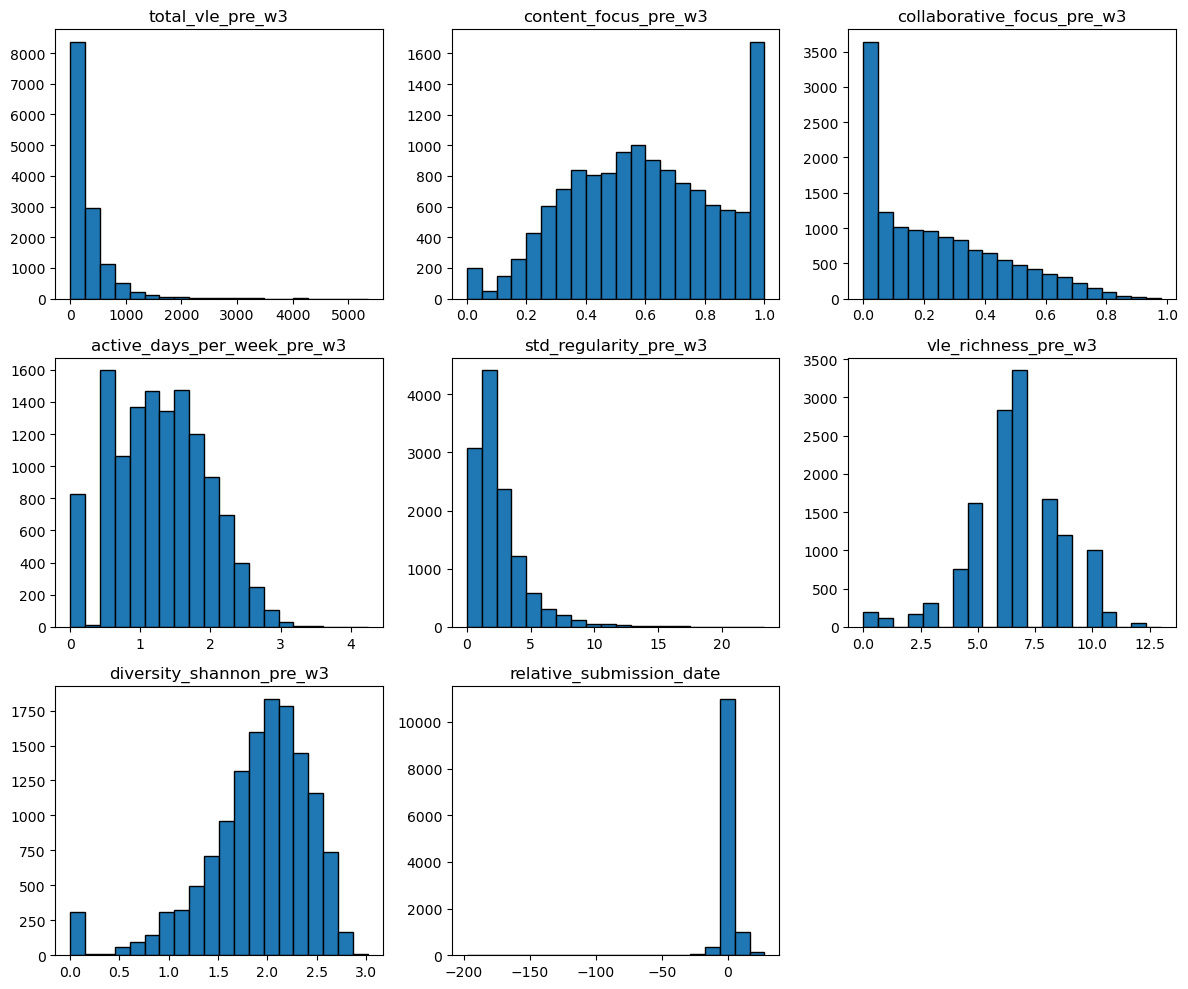

In [6]:
columns_to_display = ['total_vle_pre_w3', 'content_focus_pre_w3',
       'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
       'std_regularity_pre_w3', 'vle_richness_pre_w3',
       'diversity_shannon_pre_w3', 'relative_submission_date',
       'submission_type']

# Select only the specified columns and create histograms
df[columns_to_display].hist(bins=20, figsize=(12, 10), edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

In [9]:
# Set random seed for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


Distribution of final_result:

Absolute counts:
final_result
Pass           6240
Fail           3018
Withdrawn      2676
Distinction    1537
Name: count, dtype: int64

Percentage distribution:
final_result
Pass           46.321728
Fail           22.403682
Withdrawn      19.864895
Distinction    11.409695
Name: proportion, dtype: float64


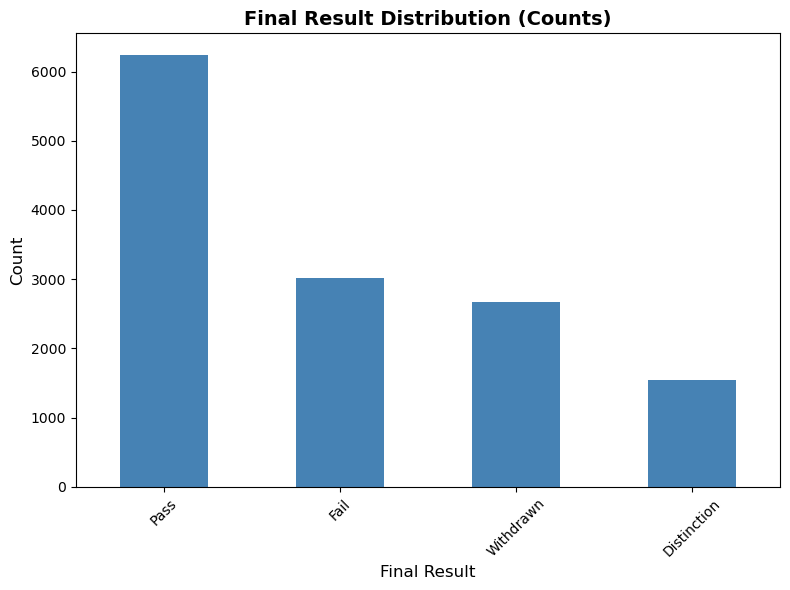


Total students: 13471
Unique categories: 4


In [8]:
# Examine the distribution of final_result

print("Distribution of final_result:")
print("=" * 50)

# Count by category
print("\nAbsolute counts:")
print(df['final_result'].value_counts())

# Percentage distribution
print("\nPercentage distribution:")
print(df['final_result'].value_counts(normalize=True) * 100)

# Visualization - counts only
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

df['final_result'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Final Result Distribution (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 50)
print(f"Total students: {len(df)}")
print(f"Unique categories: {df['final_result'].nunique()}")

## Data preprocessing

In [39]:
from sklearn.model_selection import train_test_split

# Create binary target variable
# 1 = Fail/Withdrawn 
# 0 = Pass/Distinction 
df['target'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

# Create a copy of the original df with the features we need
feature_columns = [
    'code_module', 
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3', 
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3', 
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3', 
    'relative_submission_date',
    'submission_type',
    'total_vle_pre_w3'
    #'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability'
]

# Create working dataframe with features + target
df_model = df[feature_columns + ['target']].copy()

# Assign zeros to all interaction features that are null *except* submission_type

columns_to_fill_zeros = [
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3',
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3',
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3',
    'total_vle_pre_w3',
    'relative_submission_date'
]

df_model[columns_to_fill_zeros] = df_model[columns_to_fill_zeros].fillna(0)
df_model['submission_type'] = df_model['submission_type'].fillna('Late')

df_model_clean = df_model.dropna()

# Separate features and target before encoding

X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Save code_module for stratification before encoding
code_module_for_stratification = X['code_module'].copy()

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns = ['code_module', 'submission_type'], drop_first=True)

# Create combined stratification column (target + code_module)

stratify_column = y.astype(str) + '_' + code_module_for_stratification

X_encoded["stratify"] = stratify_column

# Train/test split with stratification on the target variable
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

X_test.drop(["stratify"], axis=1, inplace=True)

# Verify split distributions

print("\nTarget distribution:")
print("-" * 60)
print(f"Original (1 = At-Risk): {y.value_counts(normalize = True).sort_index().values}")
print(f"Train (1 = At-Risk):    {y_train.value_counts(normalize = True).sort_index().values}")
print(f"Test (1 = At-Risk):     {y_test.value_counts(normalize = True).sort_index().values}")

print("\nModule distribution:")
print("-" * 60)
train_indices = X_train.index
test_indices = X_test.index

print(f"Original:   {code_module_for_stratification.value_counts(normalize = True).sort_index().values}")
print(f"Train:      {code_module_for_stratification.loc[train_indices].value_counts(normalize = True).sort_index().values}")
print(f"Test:       {code_module_for_stratification.loc[test_indices].value_counts(normalize = True).sort_index().values}")



Target distribution:
------------------------------------------------------------
Original (1 = At-Risk): [0.57731423 0.42268577]
Train (1 = At-Risk):    [0.57720861 0.42279139]
Test (1 = At-Risk):     [0.57773655 0.42226345]

Module distribution:
------------------------------------------------------------
Original:   [0.05062727 0.39588746 0.24927622 0.08863485 0.2155742 ]
Train:      [0.05057535 0.39587973 0.24935041 0.08862287 0.21557164]
Test:       [0.05083488 0.39591837 0.24897959 0.08868275 0.21558442]


In [41]:
df_model.isna().sum()

code_module                    0
content_focus_pre_w3           0
collaborative_focus_pre_w3     0
active_days_per_week_pre_w3    0
std_regularity_pre_w3          0
vle_richness_pre_w3            0
diversity_shannon_pre_w3       0
relative_submission_date       0
submission_type                0
total_vle_pre_w3               0
target                         0
dtype: int64

In [55]:
X_train

,content_focus_pre_w3,collaborative_focus_pre_w3,active_days_per_week_pre_w3,std_regularity_pre_w3,vle_richness_pre_w3,diversity_shannon_pre_w3,relative_submission_date,total_vle_pre_w3,code_module_BBB,code_module_CCC,code_module_DDD,code_module_FFF,submission_type_Late,submission_type_Never,stratify
10553,0.805556,0.194444,0.577350,1.258306,7,1.945885,-8.0,144.0,True,False,False,False,False,False,0_BBB
13443,0.642317,0.277078,1.000000,3.000000,8,2.533272,21.0,397.0,False,False,False,True,True,False,0_FFF
4367,0.325217,0.673043,2.049390,0.887041,8,1.585417,-1.0,575.0,True,False,False,False,False,False,1_BBB
12928,0.929688,0.070312,0.577350,2.509980,5,1.593788,-4.0,128.0,False,False,False,False,False,False,0_AAA
8134,0.670330,0.324176,1.788854,1.076152,9,2.386976,0.0,364.0,False,False,False,True,False,False,0_FFF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2874,0.879433,0.113475,0.707107,22.627417,8,2.092090,0.0,141.0,False,False,False,True,False,False,1_FFF
3213,0.669261,0.319066,1.673320,5.205366,9,2.434992,1.0,257.0,False,False,True,False,True,False,1_DDD
557,0.877934,0.122066,0.957427,1.193416,5,2.173140,18.0,213.0,True,False,False,False,True,False,1_BBB
991,1.000000,0.000000,0.000000,0.000000,5,1.522713,0.0,105.0,False,False,False,True,False,False,1_FFF


## Define models

In [92]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd


# Prepare scaled data
scaler = RobustScaler()

dummy_fit = scaler.fit_transform(X_train[X_train.columns[:-1]])
preprocessor = ColumnTransformer(
    transformers=[
            ('scale', scaler, X_train.columns[:-1]),
            ('passthrough_cols', 'passthrough', ["stratify"])
        ])
X_train_scaled_std = pd.DataFrame(preprocessor.fit_transform(X_train))
X_test_scaled_std = scaler.transform(X_test)


# Define models
models = {
    'Baseline (Stratified)': {
        'model': DummyClassifier(strategy='stratified', random_state=42),
        'X_train': X_train,
        'X_test': X_test
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=5000, solver='saga',
                                    penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                    class_weight='balanced'),
        'X_train': X_train_scaled_std,
        'X_test': X_test_scaled_std
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6,
                                       min_samples_split=50, min_samples_leaf=25,
                                       max_features='sqrt', max_samples=0.7,
                                       class_weight='balanced'),
        'X_train': X_train,
        'X_test': X_test
    }
}

# Helper functions
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def calculate_geometric_mean(y_true, y_pred):
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = calculate_specificity(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

## Train and compare models

In [17]:
from sklearn.base import clone

In [ ]:
# Train and evaluate with cross-validation

results = []

# scikit-learn's built-in StratifiedKFold will only stratify on one column, we're trying to stratify on two.

for model_name, config in models.items():
    auc, recall, specificity, gmean, overfit_gap = [], [], [], [], []

    for i in range(5):
        X_tt, X_ho, y_tt, y_ho = train_test_split(
            config['X_train'],
            y_train,
            test_size = 0.2,
            stratify = config['X_train'][config['X_train'].columns[-1]],
            random_state = SEED * (i+1)
        )
        X_tt.drop(X_tt.columns[-1],axis=1,inplace=True)
        X_ho.drop(X_ho.columns[-1],axis=1,inplace=True)
        
        model = clone(config['model'])
        model.fit(X_tt, y_tt)
    
        # Predictions
        y_test_pred = model.predict(X_ho)
        y_train_pred = model.predict(X_tt)
    
        # Probabilities
        try:
            y_test_proba = model.predict_proba(X_ho)[:, 1]
            y_train_proba = model.predict_proba(X_tt)[:, 1]
            test_auc = roc_auc_score(y_ho, y_test_proba)
            train_auc = roc_auc_score(y_tt, y_train_proba)
        except:
            test_auc = train_auc = np.nan

        # individual fold metrics
        auc += [test_auc]
        recall += [recall_score(y_ho, y_test_pred, zero_division=0)]
        specificity += [calculate_specificity(y_ho, y_test_pred)]
        gmean += [calculate_geometric_mean(y_ho, y_test_pred)]
        overfit_gap += [accuracy_score(y_tt, y_train_pred) - accuracy_score(y_ho, y_test_pred)]

        # 1. LOGISTIC REGRESSION: Direction of effects
        if model_name == "Logistic Regression":
            lr_importance = pd.DataFrame({
                'Feature': X_tt.columns,
                'Coefficient': model.coef_[0],
                'Abs_Coefficient': np.abs(model.coef_[0])
            }).sort_values('Abs_Coefficient', ascending=False)
        # 2. RANDOM FOREST: Importance scores
        elif model_name == "Random Forest":
            rf_importance = pd.DataFrame({
                'Feature': X_tt.columns,
                'Importance': model.feature_importances_
            }).sort_values('Importance', ascending=False)

    
    # Metrics averaged across all folds
    results.append({
        'Model': model_name,
        'Test ROC-AUC': np.mean(auc),
        'Test Recall': np.mean(recall),
        'Test Specificity': np.mean(specificity),
        'Test G-Mean': np.mean(gmean),
        'Overfitting Gap': np.mean(overfit_gap)
    })

results_df = pd.DataFrame(results).sort_values('Test G-Mean', ascending=False)

In [107]:
# Display results
print("\nMODEL PERFORMANCE (Test Set)")
print("-" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Get baseline and best model
baseline = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
best = results_df.iloc[0]

print(f"\n✓ WINNER: {best['Model']}")
print(f"  • ROC-AUC: {best['Test ROC-AUC']:.3f} (+{best['Test ROC-AUC'] - baseline['Test ROC-AUC']:.3f} vs baseline)")
print(f"  • Recall: {best['Test Recall']:.1%} of at-risk students identified")
print(f"  • Specificity: {best['Test Specificity']:.1%} of successful students correctly classified")
print(f"  • Overfitting: {best['Overfitting Gap']:.3f} {'✓ Well-controlled' if best['Overfitting Gap'] < 0.10 else '⚠ Moderate'}")

print(f"\n✓ RUNNER-UP: {results_df.iloc[1]['Model']}")
runner_up = results_df.iloc[1]
print(f"  • ROC-AUC: {runner_up['Test ROC-AUC']:.3f}")
print(f"  • Highly interpretable (coefficients show feature effects)")
print(f"  • Overfitting: {runner_up['Overfitting Gap']:.3f} {'✓ Excellent' if abs(runner_up['Overfitting Gap']) < 0.05 else '✓ Good'}")

print("\n" + "=" * 80)
print("RECOMMENDATION")
print("=" * 80)
print(f"Use {best['Model']} for deployment (best predictive performance)")
print(f"Use {results_df.iloc[1]['Model']} when interpretability is needed")


MODEL PERFORMANCE (Test Set)
--------------------------------------------------------------------------------
                Model  Test ROC-AUC  Test Recall  Test Specificity  Test G-Mean  Overfitting Gap
  Logistic Regression        0.7143       0.6235            0.6879       0.6549          -0.0060
        Random Forest        0.7118       0.6013            0.7076       0.6521           0.0100
Baseline (Stratified)        0.4982       0.4288            0.5676       0.4933          -0.0017

KEY INSIGHTS

✓ WINNER: Logistic Regression
  • ROC-AUC: 0.714 (+0.216 vs baseline)
  • Recall: 62.3% of at-risk students identified
  • Specificity: 68.8% of successful students correctly classified
  • Overfitting: -0.006 ✓ Well-controlled

✓ RUNNER-UP: Random Forest
  • ROC-AUC: 0.712
  • Highly interpretable (coefficients show feature effects)
  • Overfitting: 0.010 ✓ Excellent

RECOMMENDATION
Use Logistic Regression for deployment (best predictive performance)
Use Random Forest when interpr

## Further analysis of results

FEATURE IMPORTANCE ANALYSIS

FEATURE IMPORTANCE (Ranked by consensus across both models)
----------------------------------------------------------------------------------------------------
Rank   Feature                             LR Effect    LR Rank   RF Rank  
----------------------------------------------------------------------------------------------------
1      submission_type_Never               ↑ Risk       #1        #1       
3      submission_type_Late                ↓ Risk       #2        #4       
3      relative_submission_date            ↓ Risk       #4        #2       
4      std_regularity_pre_w3               ↑ Risk       #3        #6       
7      active_days_per_week_pre_w3         ↓ Risk       #8        #7       
8      code_module_FFF                     ↑ Risk       #5        #11      
8      total_vle_pre_w3                    ↓ Risk       #13       #3       
8      collaborative_focus_pre_w3          ↓ Risk       #11       #5       
9      diversity_shannon_

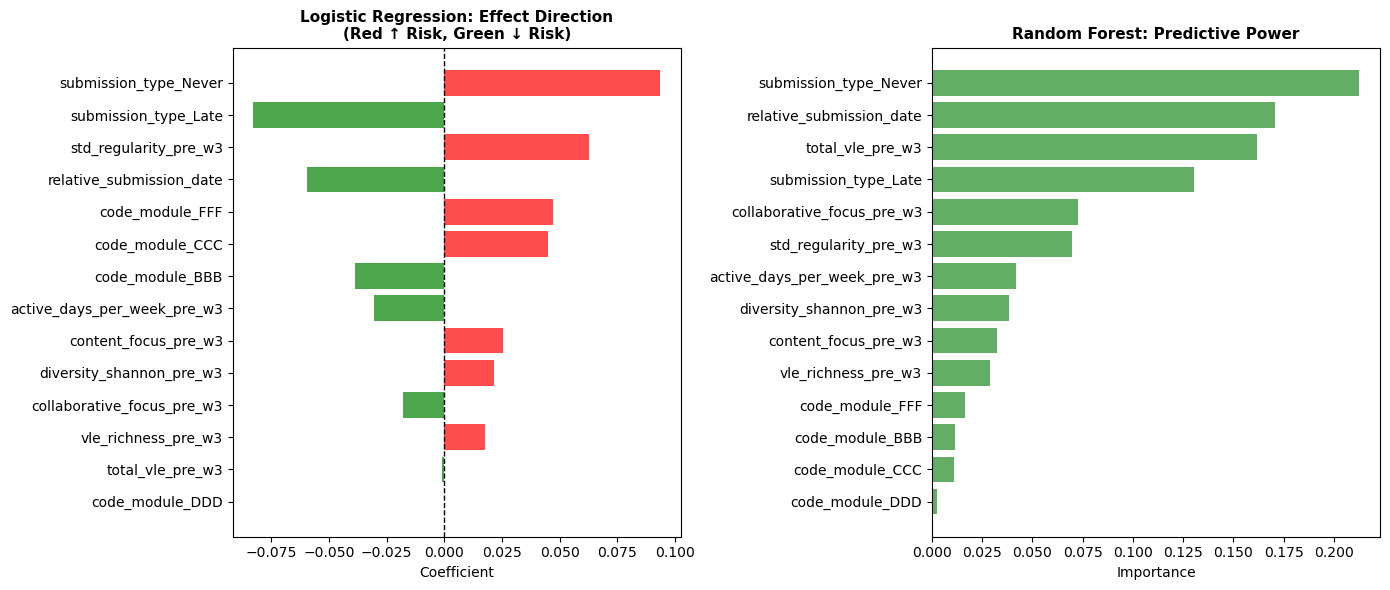


TOP 3 MOST IMPORTANT FEATURES

1. submission_type_Never
   → Higher values increases risk of failure/withdrawal
   → Consistently important across both models (Avg Rank: 1.0)

2. submission_type_Late
   → Higher values decreases risk of failure/withdrawal
   → Consistently important across both models (Avg Rank: 3.0)

3. relative_submission_date
   → Higher values decreases risk of failure/withdrawal
   → Consistently important across both models (Avg Rank: 3.0)


In [108]:
print("=" * 100)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 100)

# Get models (use last fold)
# lr_model = models['Logistic Regression']['model']
# lr_model.fit(X_tt, y_tt)

# rf_model = models['Random Forest']['model']
# rf_model.fit(X_tt, y_tt)

# feature_names = X_tt.columns

# 1. LOGISTIC REGRESSION: Direction of effects
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

# 2. RANDOM FOREST: Importance scores
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# 3. CONSENSUS RANKING
lr_importance['LR_Rank'] = range(1, len(lr_importance) + 1)
rf_importance['RF_Rank'] = range(1, len(rf_importance) + 1)

consensus = lr_importance[['Feature', 'Coefficient', 'LR_Rank']].merge(
    rf_importance[['Feature', 'Importance', 'RF_Rank']], on='Feature'
)
consensus['Avg_Rank'] = (consensus['LR_Rank'] + consensus['RF_Rank']) / 2
consensus = consensus.sort_values('Avg_Rank')

# DISPLAY: Consensus ranking with effects
print("\nFEATURE IMPORTANCE (Ranked by consensus across both models)")
print("-" * 100)
print(f"{'Rank':<6} {'Feature':<35} {'LR Effect':<12} {'LR Rank':<9} {'RF Rank':<9}")
print("-" * 100)

for idx, row in consensus.iterrows():
    rank = int(row['Avg_Rank'])
    feature = row['Feature']
    effect = "↑ Risk" if row['Coefficient'] > 0 else "↓ Risk"
    lr_rank = int(row['LR_Rank'])
    rf_rank = int(row['RF_Rank'])
    
    print(f"{rank:<6} {feature:<35} {effect:<12} #{lr_rank:<8} #{rf_rank:<8}")

print("\n" + "-" * 100)
print("KEY:")
print("  ↑ Risk = Higher values increase risk of Fail/Withdrawal")
print("  ↓ Risk = Higher values decrease risk of Fail/Withdrawal")
print("-" * 100)

# VISUALIZATION: Single comprehensive plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Logistic Regression coefficients (with direction)
colors = ['red' if c > 0 else 'green' for c in lr_importance['Coefficient']]
axes[0].barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors, alpha=0.7)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Coefficient', fontsize=10)
axes[0].set_title('Logistic Regression: Effect Direction\n(Red ↑ Risk, Green ↓ Risk)', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()

# Right: Random Forest importance
axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='forestgreen', alpha=0.7)
axes[1].set_xlabel('Importance', fontsize=10)
axes[1].set_title('Random Forest: Predictive Power', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# TOP 3 INSIGHTS
print("\n" + "=" * 100)
print("TOP 3 MOST IMPORTANT FEATURES")
print("=" * 100)

for i, (idx, row) in enumerate(consensus.head(3).iterrows(), 1):
    feature = row['Feature']
    effect = "increases" if row['Coefficient'] > 0 else "decreases"
    
    print(f"\n{i}. {feature}")
    print(f"   → Higher values {effect} risk of failure/withdrawal")
    print(f"   → Consistently important across both models (Avg Rank: {row['Avg_Rank']:.1f})")

## Analysis with confusion matrices and classification thresholds

The rest of this code has not been updated after the training code was updated to use cross-validation.

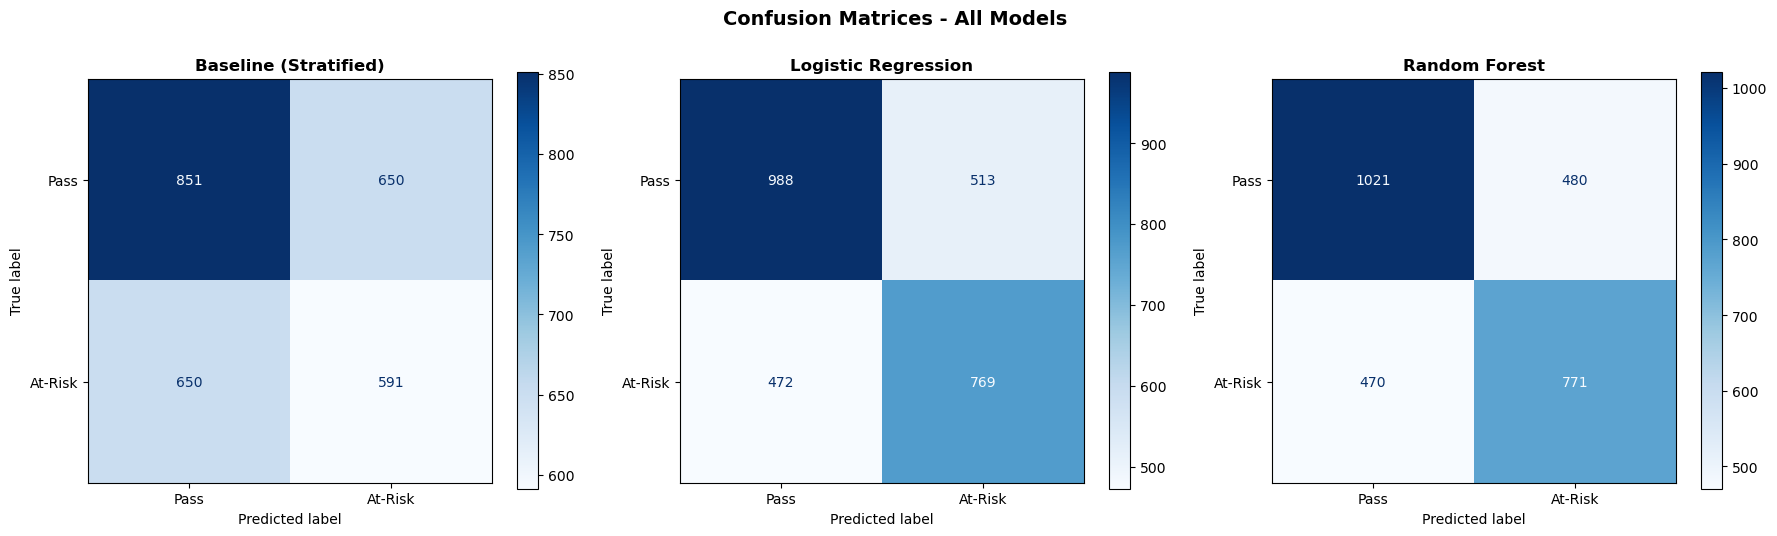


CONFUSION MATRIX DETAILS

Baseline (Stratified):
--------------------------------------------------------------------------------
  True Negatives (TN):     851 - Correctly predicted Pass/Distinction
  False Positives (FP):    650 - Incorrectly predicted At-Risk
  False Negatives (FN):    650 - Missed at-risk students
  True Positives (TP):     591 - Correctly identified at-risk students

Logistic Regression:
--------------------------------------------------------------------------------
  True Negatives (TN):     988 - Correctly predicted Pass/Distinction
  False Positives (FP):    513 - Incorrectly predicted At-Risk
  False Negatives (FN):    472 - Missed at-risk students
  True Positives (TP):     769 - Correctly identified at-risk students

Random Forest:
--------------------------------------------------------------------------------
  True Negatives (TN):   1,021 - Correctly predicted Pass/Distinction
  False Positives (FP):    480 - Incorrectly predicted At-Risk
  False Negati

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create subplots for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

base_model = DummyClassifier(strategy='stratified', random_state=42)
base_model.fit(X_tt,y_tt)

model_configs = [
    ('Baseline (Stratified)', base_model, 
     models['Baseline (Stratified)']['X_test']),
    ('Logistic Regression', models['Logistic Regression']['model'], 
     models['Logistic Regression']['X_test']),
    ('Random Forest', models['Random Forest']['model'], 
     models['Random Forest']['X_test'])
]

for idx, (model_name, model, X_ho_data) in enumerate(model_configs):
    # Get predictions
    y_test_pred = model.predict(X_test_data)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    
    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Pass', 'At-Risk'])
    disp.plot(cmap='Blues', ax=axes[idx], values_format='d')
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed breakdown for each model
print("\n" + "=" * 80)
print("CONFUSION MATRIX DETAILS")
print("=" * 80)

for model_name, model, X_test_data in model_configs:
    y_test_pred = model.predict(X_test_data)
    cm = confusion_matrix(y_test, y_test_pred)
    
    print(f"\n{model_name}:")
    print("-" * 80)
    print(f"  True Negatives (TN):  {cm[0, 0]:>6,} - Correctly predicted Pass/Distinction")
    print(f"  False Positives (FP): {cm[0, 1]:>6,} - Incorrectly predicted At-Risk")
    print(f"  False Negatives (FN): {cm[1, 0]:>6,} - Missed at-risk students")
    print(f"  True Positives (TP):  {cm[1, 1]:>6,} - Correctly identified at-risk students")

The model is okay, but it doesn't do a great job of flagging at-risk students (as measured by recall). What if we adjust the thresholds? What are the tradeoffs in that scenario?

THRESHOLD TUNING COMPARISON: Random Forest vs Logistic Regression

RANDOM FOREST

Threshold = 0.3
  False Negatives:   83 (missing 6.7% of at-risk students)
  Recall:           93.3% (catching 93.3% of at-risk students)
  Precision:        49.9%
  False Positives: 1162

Threshold = 0.4
  False Negatives:  219 (missing 17.6% of at-risk students)
  Recall:           82.4% (catching 82.4% of at-risk students)
  Precision:        54.5%
  False Positives:  853

Threshold = 0.5
  False Negatives:  470 (missing 37.9% of at-risk students)
  Recall:           62.1% (catching 62.1% of at-risk students)
  Precision:        61.6%
  False Positives:  480

Threshold = 0.6
  False Negatives:  751 (missing 60.5% of at-risk students)
  Recall:           39.5% (catching 39.5% of at-risk students)
  Precision:        70.7%
  False Positives:  203

LOGISTIC REGRESSION

Threshold = 0.3
  False Negatives:   72 (missing 5.8% of at-risk students)
  Recall:           94.2% (catching 94.2% of at-risk students)


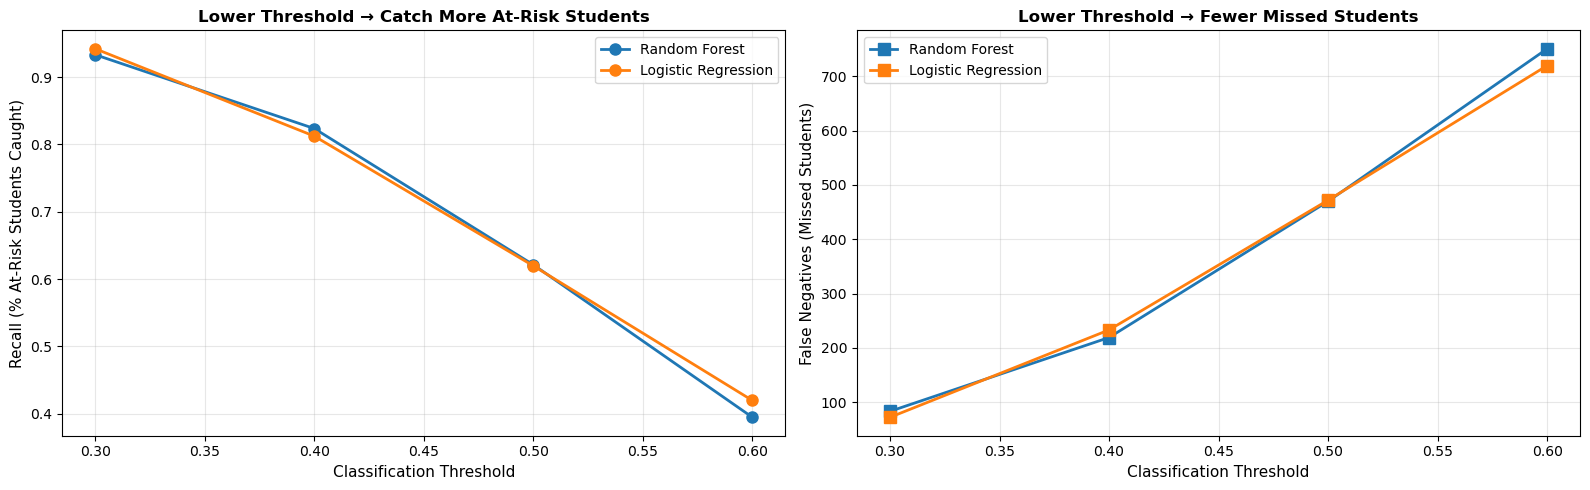


RECOMMENDATION
Compare both models at your desired threshold to see which performs better
for your specific recall/precision trade-off needs.


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get both models
rf_model = models['Random Forest']['model']
lr_model = models['Logistic Regression']['model']

# Get predicted probabilities for both
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_test_proba_lr = lr_model.predict_proba(X_test_scaled_std)[:, 1]

# Test different thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6]

print("=" * 90)
print("THRESHOLD TUNING COMPARISON: Random Forest vs Logistic Regression")
print("=" * 90)

all_results = []

for model_name, y_proba in [('Random Forest', y_test_proba_rf), 
                             ('Logistic Regression', y_test_proba_lr)]:
    print(f"\n{'='*90}")
    print(f"{model_name.upper()}")
    print(f"{'='*90}")
    
    for threshold in thresholds_to_test:
        # Apply custom threshold
        y_pred_threshold = (y_proba >= threshold).astype(int)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_test, y_pred_threshold)
        tn, fp, fn, tp = cm.ravel()
        
        # Calculate metrics
        recall = tp / (tp + fn)
        specificity = tn / (tn + fp)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        all_results.append({
            'Model': model_name,
            'Threshold': threshold,
            'FN (Missed)': fn,
            'Recall': recall,
            'Specificity': specificity,
            'Precision': precision,
            'FP (False Alarms)': fp
        })
        
        print(f"\nThreshold = {threshold:.1f}")
        print(f"  False Negatives: {fn:>4} (missing {fn/(tp+fn)*100:.1f}% of at-risk students)")
        print(f"  Recall:          {recall:>6.1%} (catching {recall*100:.1f}% of at-risk students)")
        print(f"  Precision:       {precision:>6.1%}")
        print(f"  False Positives: {fp:>4}")

# Visualize comparison
results_df = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Recall comparison
for model in ['Random Forest', 'Logistic Regression']:
    model_data = results_df[results_df['Model'] == model]
    axes[0].plot(model_data['Threshold'], model_data['Recall'], 
                 'o-', linewidth=2, markersize=8, label=model)
axes[0].set_xlabel('Classification Threshold', fontsize=11)
axes[0].set_ylabel('Recall (% At-Risk Students Caught)', fontsize=11)
axes[0].set_title('Lower Threshold → Catch More At-Risk Students', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: False Negatives comparison
for model in ['Random Forest', 'Logistic Regression']:
    model_data = results_df[results_df['Model'] == model]
    axes[1].plot(model_data['Threshold'], model_data['FN (Missed)'], 
                 's-', linewidth=2, markersize=8, label=model)
axes[1].set_xlabel('Classification Threshold', fontsize=11)
axes[1].set_ylabel('False Negatives (Missed Students)', fontsize=11)
axes[1].set_title('Lower Threshold → Fewer Missed Students', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

~0.4 threshold might be close to a sweet spot. Below I compare Random Forest and Logistic Regression to the stratified baseline:

MODEL COMPARISON AT THRESHOLD = 0.4
Optimized for Higher Recall (Catching More At-Risk Students)

MODEL PERFORMANCE METRICS
------------------------------------------------------------------------------------------
                Model Threshold  Test ROC-AUC  Recall  Specificity  Precision  F1-Score  Accuracy
Baseline (Stratified)       N/A        0.5216  0.4762       0.5670     0.4762    0.4762    0.5259
  Logistic Regression    0.4000        0.7025  0.8122       0.4417     0.5460    0.6531    0.6094
        Random Forest    0.4000        0.7125  0.8235       0.4317     0.5451    0.6560    0.6090

CONFUSION MATRIX BREAKDOWN

Baseline (Stratified):
------------------------------------------------------------------------------------------
  True Negatives (TN):     851 - Correctly predicted Pass/Distinction
  False Positives (FP):    650 - Incorrectly predicted At-Risk
  False Negatives (FN):    650 - Missed at-risk students ⚠️
  True Positives (TP):     591 - Correctly identified at-

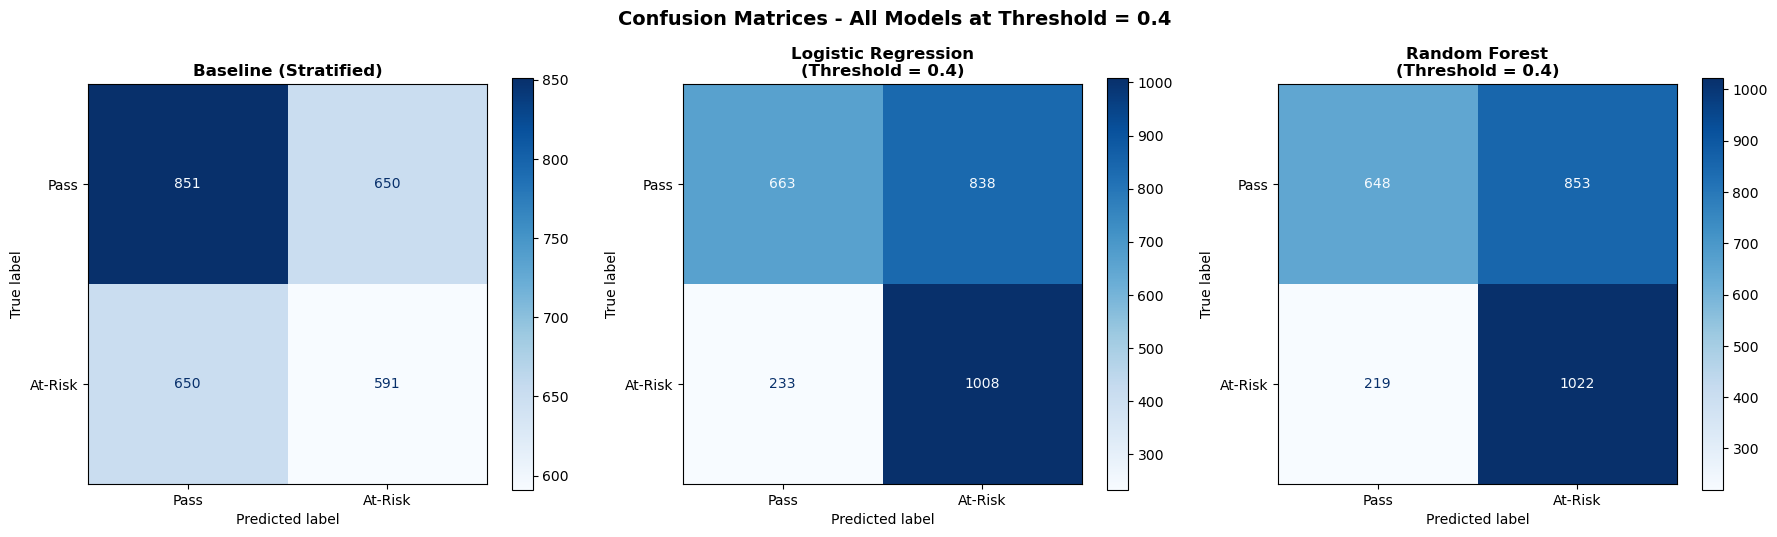


KEY INSIGHTS

✓ BEST FOR CATCHING AT-RISK STUDENTS (Highest Recall): Random Forest
  • Recall: 82.4%
  • Only misses 219 out of 1241 at-risk students
  • Trade-off: 853 false alarms

✓ BEST FOR ACCURACY OF AT-RISK PREDICTIONS (Highest Precision): Logistic Regression
  • Precision: 54.6%
  • 54.6% of students flagged as at-risk truly are at-risk

✓ BEST OVERALL BALANCE (Highest F1-Score): Random Forest
  • F1-Score: 0.656
  • Balanced performance between recall and precision

IMPROVEMENT OVER DEFAULT THRESHOLD (0.5)

Random Forest:
  • False Negatives: 470 → 219 (53.4% reduction)
  • Recall: 62.1% → 82.4% (+20.3 percentage points)

RECOMMENDATION
Deploy: Random Forest with threshold = 0.4
  → Maximizes recall while maintaining acceptable precision
  → Catches 82.4% of at-risk students
  → Only 219 at-risk students will be missed


In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("MODEL COMPARISON AT THRESHOLD = 0.4")
print("Optimized for Higher Recall (Catching More At-Risk Students)")
print("=" * 90)

# Define threshold
threshold = 0.4

# Get models and their test data
model_configs = {
    'Baseline (Stratified)': {
        'model': models['Baseline (Stratified)']['model'],
        'X_test': models['Baseline (Stratified)']['X_test']
    },
    'Logistic Regression': {
        'model': models['Logistic Regression']['model'],
        'X_test': models['Logistic Regression']['X_test']
    },
    'Random Forest': {
        'model': models['Random Forest']['model'],
        'X_test': models['Random Forest']['X_test']
    }
}

# Helper function
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def calculate_geometric_mean(y_true, y_pred):
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = calculate_specificity(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

# Evaluate each model
results = []
confusion_matrices = {}

for model_name, config in model_configs.items():
    model = config['model']
    X_test_data = config['X_test']
    
    # Get probabilities and apply threshold
    try:
        y_test_proba = model.predict_proba(X_test_data)[:, 1]
        y_test_pred = (y_test_proba >= threshold).astype(int)
        test_auc = roc_auc_score(y_test, y_test_proba)
    except:
        # Baseline doesn't support predict_proba reliably
        y_test_pred = model.predict(X_test_data)
        test_auc = np.nan
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    confusion_matrices[model_name] = cm
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate metrics
    results.append({
        'Model': model_name,
        'Threshold': threshold if model_name != 'Baseline (Stratified)' else 'N/A',
        'Test ROC-AUC': test_auc,
        'Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'Specificity': calculate_specificity(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_test_pred, zero_division=0),
        'G-Mean': calculate_geometric_mean(y_test, y_test_pred),
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

results_df = pd.DataFrame(results)

# Display performance metrics
print("\nMODEL PERFORMANCE METRICS")
print("-" * 90)
metrics_display = results_df[['Model', 'Threshold', 'Test ROC-AUC', 'Recall', 
                               'Specificity', 'Precision', 'F1-Score', 'Accuracy']]
print(metrics_display.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Display confusion matrix breakdown
print("\n" + "=" * 90)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 90)

for _, row in results_df.iterrows():
    print(f"\n{row['Model']}:")
    print("-" * 90)
    print(f"  True Negatives (TN):  {row['TN']:>6,} - Correctly predicted Pass/Distinction")
    print(f"  False Positives (FP): {row['FP']:>6,} - Incorrectly predicted At-Risk")
    print(f"  False Negatives (FN): {row['FN']:>6,} - Missed at-risk students ⚠️")
    print(f"  True Positives (TP):  {row['TP']:>6,} - Correctly identified at-risk students ✓")
    print(f"  → Recall: {row['Recall']:.1%} (catching {row['Recall']*100:.1f}% of at-risk students)")
    print(f"  → Precision: {row['Precision']:.1%} ({row['Precision']*100:.1f}% of at-risk predictions are correct)")

# Visualization: Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    from sklearn.metrics import ConfusionMatrixDisplay
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Pass', 'At-Risk'])
    disp.plot(cmap='Blues', ax=axes[idx], values_format='d')
    
    # Add threshold to title if applicable
    title = model_name
    if model_name != 'Baseline (Stratified)':
        title += f'\n(Threshold = {threshold})'
    
    axes[idx].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - All Models at Threshold = 0.4', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Key insights
print("\n" + "=" * 90)
print("KEY INSIGHTS")
print("=" * 90)

best_recall = results_df.loc[results_df['Recall'].idxmax()]
best_precision = results_df.loc[results_df['Precision'].idxmax()]
best_f1 = results_df.loc[results_df['F1-Score'].idxmax()]
fewest_fn = results_df.loc[results_df['FN'].idxmin()]

print(f"\n✓ BEST FOR CATCHING AT-RISK STUDENTS (Highest Recall): {best_recall['Model']}")
print(f"  • Recall: {best_recall['Recall']:.1%}")
print(f"  • Only misses {best_recall['FN']} out of {best_recall['FN'] + best_recall['TP']} at-risk students")
print(f"  • Trade-off: {best_recall['FP']} false alarms")

print(f"\n✓ BEST FOR ACCURACY OF AT-RISK PREDICTIONS (Highest Precision): {best_precision['Model']}")
print(f"  • Precision: {best_precision['Precision']:.1%}")
print(f"  • {best_precision['Precision']*100:.1f}% of students flagged as at-risk truly are at-risk")

print(f"\n✓ BEST OVERALL BALANCE (Highest F1-Score): {best_f1['Model']}")
print(f"  • F1-Score: {best_f1['F1-Score']:.3f}")
print(f"  • Balanced performance between recall and precision")

# Comparison to default threshold (0.5)
print("\n" + "=" * 90)
print("IMPROVEMENT OVER DEFAULT THRESHOLD (0.5)")
print("=" * 90)

print("\nRandom Forest:")
print(f"  • False Negatives: 470 → {results_df[results_df['Model']=='Random Forest']['FN'].values[0]} ({(1 - results_df[results_df['Model']=='Random Forest']['FN'].values[0]/470)*100:.1f}% reduction)")
print(f"  • Recall: 62.1% → {results_df[results_df['Model']=='Random Forest']['Recall'].values[0]:.1%} (+{(results_df[results_df['Model']=='Random Forest']['Recall'].values[0] - 0.621)*100:.1f} percentage points)")

print("\n" + "=" * 90)
print("RECOMMENDATION")
print("=" * 90)
print(f"Deploy: {best_recall['Model']} with threshold = {threshold}")
print(f"  → Maximizes recall while maintaining acceptable precision")
print(f"  → Catches {best_recall['Recall']*100:.1f}% of at-risk students")
print(f"  → Only {best_recall['FN']} at-risk students will be missed")

We're still making sacrifices, however. Below I model the tradeoffs between recall, specificity, and precision at different thresholds.

PRECISION-RECALL-SPECIFICITY TRADE-OFF


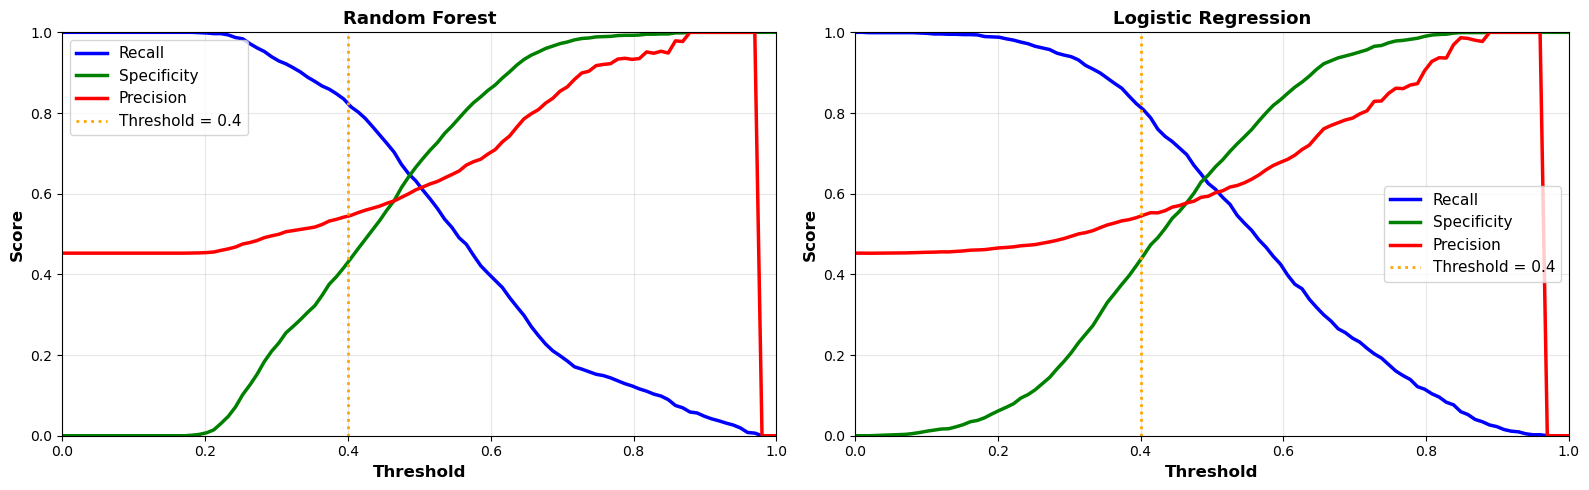


METRICS AT THRESHOLD = 0.4
--------------------------------------------------------------------------------

Model                Recall       Specificity     Precision   
--------------------------------------------------------------------------------
Random Forest             81.5%          44.0%       54.6%
Logistic Regression       80.8%          44.6%       54.7%

KEY INSIGHT
Lower threshold → Higher recall (catch more at-risk)
                → Lower specificity & precision (more false alarms)


In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 80)
print("PRECISION-RECALL-SPECIFICITY TRADE-OFF")
print("=" * 80)

# Get models and probabilities
rf_model = models['Random Forest']['model']
lr_model = models['Logistic Regression']['model']
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_test_proba_lr = lr_model.predict_proba(X_test_scaled_std)[:, 1]

# Calculate metrics across thresholds
def calculate_metrics(y_true, y_proba, thresholds):
    metrics = {'precision': [], 'recall': [], 'specificity': []}
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        metrics['precision'].append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        metrics['recall'].append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        metrics['specificity'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    
    return metrics

# Calculate for both models
thresholds = np.linspace(0, 1, 100)
metrics_rf = calculate_metrics(y_test, y_test_proba_rf, thresholds)
metrics_lr = calculate_metrics(y_test, y_test_proba_lr, thresholds)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Random Forest
idx_40 = np.argmin(np.abs(thresholds - 0.4))
ax1.plot(thresholds, metrics_rf['recall'], 'b-', linewidth=2.5, label='Recall')
ax1.plot(thresholds, metrics_rf['specificity'], 'g-', linewidth=2.5, label='Specificity')
ax1.plot(thresholds, metrics_rf['precision'], 'r-', linewidth=2.5, label='Precision')
ax1.axvline(x=0.4, color='orange', linestyle=':', linewidth=2, label='Threshold = 0.4')
ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Random Forest', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Logistic Regression
ax2.plot(thresholds, metrics_lr['recall'], 'b-', linewidth=2.5, label='Recall')
ax2.plot(thresholds, metrics_lr['specificity'], 'g-', linewidth=2.5, label='Specificity')
ax2.plot(thresholds, metrics_lr['precision'], 'r-', linewidth=2.5, label='Precision')
ax2.axvline(x=0.4, color='orange', linestyle=':', linewidth=2, label='Threshold = 0.4')
ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Logistic Regression', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print key values at threshold = 0.4
print("\nMETRICS AT THRESHOLD = 0.4")
print("-" * 80)
print(f"\n{'Model':<20} {'Recall':<12} {'Specificity':<15} {'Precision':<12}")
print("-" * 80)
print(f"{'Random Forest':<20} {metrics_rf['recall'][idx_40]:>10.1%} {metrics_rf['specificity'][idx_40]:>14.1%} {metrics_rf['precision'][idx_40]:>11.1%}")
print(f"{'Logistic Regression':<20} {metrics_lr['recall'][idx_40]:>10.1%} {metrics_lr['specificity'][idx_40]:>14.1%} {metrics_lr['precision'][idx_40]:>11.1%}")

print("\n" + "=" * 80)
print("KEY INSIGHT")
print("=" * 80)
print("Lower threshold → Higher recall (catch more at-risk)")
print("                → Lower specificity & precision (more false alarms)")